# Gamma en Hull–White: estimación por diferencias finitas

**Objetivo del notebook.** Estimar la Gamma de una opción europea bajo el modelo de Hull–White mediante diferencias finitas centradas de segundo orden con *common random numbers* (CRN). El método pathwise no es aplicable: la segunda derivada del payoff $(S_T - K)^+$ respecto a $S_0$ introduce la derivada del indicador $\mathbf{1}_{\{S_T > K\}}$, que es una masa de Dirac en $S_T = K$ y no define un estimador Monte Carlo válido. El factor de descuento estocástico $D^{(n)}$ actúa como peso multiplicativo y no aporta diferenciabilidad adicional al payoff.

El estimador empleado es

$$
\widehat{\Gamma}^{\,FD} \;=\; \frac{\widehat{V}_0(S_0+h) - 2\,\widehat{V}_0(S_0) + \widehat{V}_0(S_0-h)}{h^2},
$$

con las tres valoraciones Monte Carlo compartiendo la misma semilla (mismas trayectorias del tipo corto y, por tanto, mismo $D^{(n)}$ por trayectoria).

El notebook contiene:

1. Estimación puntual con los parámetros de referencia del Cap. 4.
2. Banda de incertidumbre del estimador FD mediante repeticiones independientes.
3. Sensibilidad respecto al paso de perturbación $h$.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hullwhite import GeneratePathsHWAndAssetEuler, P0T, PriceEuropeanOptionHWMC

np.set_printoptions(suppress=True, precision=6)

## 1. Parámetros del experimento

Se adoptan los parámetros estándar del Cap. 4 (Tabla de parámetros de referencia).

In [2]:
S0          = 100.0
K           = 100.0
sigma_S     = 0.20
lambd       = 0.5
eta         = 0.01
rho         = -0.3
T           = 1.0
N           = 20_000
M           = 250
SEED        = 3
option_type = "call"

## 2. Estimador FD

Se necesitan **tres** valoraciones Monte Carlo: $\widehat{V}_0(S_0+h)$, $\widehat{V}_0(S_0)$ y $\widehat{V}_0(S_0-h)$. Las tres se generan con la misma semilla, de modo que comparten la realización de los incrementos brownianos $\{\Delta W_k^r, \Delta W_k^S\}$ y, en consecuencia, la trayectoria del tipo corto $\{r_{t_k}\}$ y el factor de descuento $D^{(n)}$. La diferencia $V_0(S_0+h) - 2V_0(S_0) + V_0(S_0-h)$ captura exclusivamente el efecto de $S_0$ sobre $S_T$.

In [3]:
def GammaFD_HW_MC(NoOfPaths, NoOfSteps, T, P0T, lambd, eta,
                  S0, sigma_S, rho, K, h,
                  option_type="call", seed=SEED):
    """
    Gamma por diferencias finitas centradas de segundo orden en Hull-White,
    con common random numbers (misma semilla en S0+h, S0 y S0-h).

    Devuelve gamma_fd y los tres precios para inspeccion.
    """
    paths_up = GeneratePathsHWAndAssetEuler(
        NoOfPaths, NoOfSteps, T, P0T, lambd, eta,
        S0 + h, sigma_S, rho, seed=seed)
    price_up, _ = PriceEuropeanOptionHWMC(paths_up, K, T, option_type)

    paths_mid = GeneratePathsHWAndAssetEuler(
        NoOfPaths, NoOfSteps, T, P0T, lambd, eta,
        S0, sigma_S, rho, seed=seed)
    price_mid, _ = PriceEuropeanOptionHWMC(paths_mid, K, T, option_type)

    paths_dn = GeneratePathsHWAndAssetEuler(
        NoOfPaths, NoOfSteps, T, P0T, lambd, eta,
        S0 - h, sigma_S, rho, seed=seed)
    price_dn, _ = PriceEuropeanOptionHWMC(paths_dn, K, T, option_type)

    gamma_fd = (price_up - 2.0 * price_mid + price_dn) / h**2
    return gamma_fd, price_up, price_mid, price_dn

## 3. Estimación puntual

Se calcula el estimador con los parámetros de referencia y $h = 0{,}5$ (perturbación del $0{,}5\,\%$ sobre $S_0 = 100$).

In [4]:
h = 0.5

gamma_fd, p_up, p_mid, p_dn = GammaFD_HW_MC(
    N, M, T, P0T, lambd, eta, S0, sigma_S, rho, K,
    h=h, option_type=option_type, seed=SEED)

print(f"V(S0 + h) = {p_up:.6f}")
print(f"V(S0)     = {p_mid:.6f}")
print(f"V(S0 - h) = {p_dn:.6f}")
print()
print(f"Gamma FD (h = {h}) = {gamma_fd:.6f}")

V(S0 + h) = 10.591672
V(S0)     = 10.273246
V(S0 - h) = 9.960132

Gamma FD (h = 0.5) = 0.021246


El valor positivo confirma la convexidad de la opción call. La banda de incertidumbre asociada a este estimador puntual se cuantifica en la siguiente sección mediante repeticiones independientes.

## 4. Banda de incertidumbre del estimador FD

La Gamma es un estimador FD-only: no existe contraste pathwise con el que comparar varianzas. Para cuantificar su precisión se repite la estimación sobre $n_{\text{rep}}$ simulaciones independientes (semillas distintas), manteniendo $N$ fijo y conservando CRN dentro de cada repetición. La desviación típica muestral de los $n_{\text{rep}}$ estimadores aproxima el error estándar de un estimador individual y proporciona una banda de incertidumbre alrededor de la estimación puntual.

In [5]:
n_rep     = 60
base_seed = 1000   # semillas 1000, 1001, ..., distintas entre repeticiones

def GammaRepeticiones_HW(n_rep, base_seed, h=0.5):
    """
    Repite la estimacion de Gamma sobre n_rep simulaciones independientes
    a N fijo. Dentro de cada repeticion se emplea CRN (misma semilla
    en las tres valoraciones internas); entre repeticiones la semilla
    cambia. La desviacion tipica muestral sobre las repeticiones estima
    el error estandar de un estimador individual.
    """
    gamma = np.empty(n_rep)
    for j in range(n_rep):
        s = base_seed + j
        gamma[j], _, _, _ = GammaFD_HW_MC(
            N, M, T, P0T, lambd, eta, S0, sigma_S, rho, K,
            h=h, option_type=option_type, seed=s)
    return gamma

gamma_rep = GammaRepeticiones_HW(n_rep, base_seed, h=h)

media_gamma = gamma_rep.mean()
se_gamma    = gamma_rep.std(ddof=1)

print(f"Repeticiones: {n_rep}   (N = {N}, M = {M}, h = {h})")
print(f"Media:    {media_gamma:.6f}")
print(f"SE (rep): {se_gamma:.6f}")
print(f"IC 95% (asintotico): [{media_gamma - 1.96*se_gamma:.6f}, {media_gamma + 1.96*se_gamma:.6f}]")

Repeticiones: 60   (N = 20000, M = 250, h = 0.5)
Media:    0.019005
SE (rep): 0.000872
IC 95% (asintotico): [0.017296, 0.020714]


La SE empírica obtenida proporciona la banda de incertidumbre que acompañará al estimador puntual en el resto del notebook. En particular, cualquier oscilación del estimador en el barrido en $h$ que quede dentro de $\pm \text{SE}$ debe atribuirse al error Monte Carlo y no a un efecto sistemático del paso de perturbación.

## 5. Sensibilidad respecto a $h$

La Gamma por FD es especialmente sensible a la elección de $h$: el divisor $h^{-2}$ amplifica el ruido Monte Carlo cuando $h$ es pequeño, mientras que el sesgo de truncamiento $\mathcal{O}(h^2)$ crece con $h$ grande. El barrido localiza el rango óptimo como el mínimo de una curva en U sobre la malla considerada.

In [9]:
h_grid = np.array([10.0, 7.0, 5.0, 3.0, 2.0, 1.0, 0.5, 0.2, 0.1, 0.05])
import pandas as pd
results = []
for h_val in h_grid:
    g, pu, pm, p_sd = GammaFD_HW_MC(
        N, M, T, P0T, lambd, eta, S0, sigma_S, rho, K,
        h=h_val, option_type=option_type, seed=SEED)
    results.append({
        "h"        : h_val,
        "V(S0+h)"  : pu,
        "V(S0)"    : pm,
        "V(S0-h)"  : p_sd,
        "Gamma_FD" : g,
    })

df_h = pd.DataFrame(results)
df_h

,h,V(S0+h),V(S0),V(S0-h),Gamma_FD
0,10.00,17.452920,10.273246,4.985811,0.018922
1,7.00,15.133632,10.273246,6.347669,0.019078
2,5.00,13.661539,10.273246,7.362969,0.019121
3,3.00,12.254367,10.273246,8.465782,0.019295
4,2.00,11.575574,10.273246,9.048888,0.019493
5,1.00,10.914984,10.273246,9.651503,0.019996
6,0.50,10.591672,10.273246,9.960132,0.021246
7,0.20,10.400055,10.273246,10.147354,0.022921
8,0.10,10.336546,10.273246,10.210181,0.023439
9,0.05,10.304868,10.273246,10.241686,0.024458


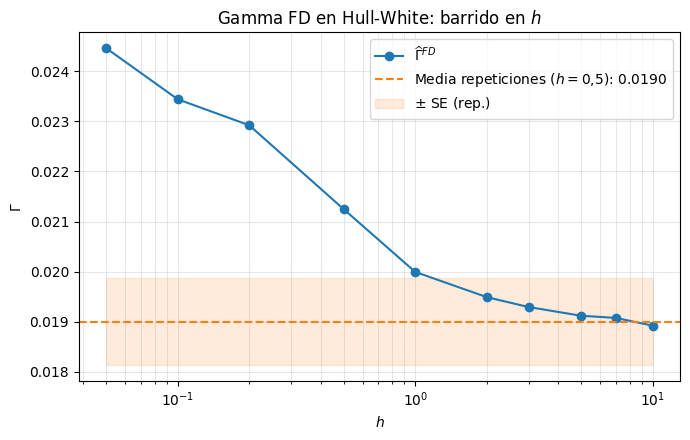

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.semilogx(df_h["h"], df_h["Gamma_FD"], marker="o", label=r"$\widehat{\Gamma}^{FD}$")
ax.axhline(media_gamma, color="C1", linestyle="--",
           label=fr"Media repeticiones $(h=0{{,}}5)$: ${media_gamma:.4f}$")
ax.fill_between(
    df_h["h"],
    media_gamma - se_gamma, media_gamma + se_gamma,
    color="C1", alpha=0.15, label=r"$\pm$ SE (rep.)"
)

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"$\Gamma$")
ax.set_title("Gamma FD en Hull-White: barrido en $h$")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura del barrido.** La banda $\pm\,\text{SE}$ obtenida por repeticiones permite separar visualmente el régimen dominado por sesgo del régimen dominado por varianza:

- **Régimen de sesgo** (valores de $\widehat{\Gamma}^{FD}$ que se separan sistemáticamente de la media con $h$ grande): identifica el rango donde el término $\mathcal{O}(h^2)$ del cociente de diferencias finitas no es despreciable.
- **Régimen estable**: rango de $h$ en el que $\widehat{\Gamma}^{FD}$ permanece dentro de la banda $\pm\,\text{SE}$.
- **Régimen de varianza** ($h$ pequeño): el divisor $h^{-2}$ amplifica el ruido residual y el estimador empieza a oscilar fuera de la banda incluso con CRN.

La localización exacta del mínimo de la curva en U se lee directamente sobre la tabla y la figura.

## 6. Conclusiones

1. La Gamma en Hull–White se estima mediante FD centrada de segundo orden con tres valoraciones bajo CRN. El método pathwise no es aplicable (delta de Dirac en la segunda derivada del payoff).
2. La banda de incertidumbre del estimador, obtenida por $n_{\text{rep}} = 50$ repeticiones independientes, sustituye al contraste con pathwise que sí existía para Delta y Vega.
3. El barrido en $h$ exhibe la estructura en U habitual: sesgo $\mathcal{O}(h^2)$ para $h$ grande y amplificación $h^{-2}$ del ruido para $h$ pequeño. CRN mitiga la segunda pero no la elimina.